Data Analysis of customer churn

https://www.kaggle.com/competitions/playground-series-s6e3/

Evaluation metric: Area under the RoC curve

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
import scipy.stats as stats

import statsmodels.api as sm
import statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Data Understanding

In [2]:
data = pd.read_csv('train.csv')
data.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [4]:
data["SeniorCitizen"] = data["SeniorCitizen"].astype("object")

In [5]:
data.describe()

,id,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,36.577258,65.866223,2494.377057
std,171529.177263,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,12.000000,29.900000,639.650000
50%,297096.500000,35.000000,74.100000,1433.650000
75%,445644.750000,62.000000,90.800000,4263.800000
max,594193.000000,72.000000,118.750000,8684.800000


In [6]:
data['tenure'].unique()

array([29, 58,  1, 24, 72, 55, 13, 67, 33, 63,  3, 31, 27, 52, 68, 35, 66,
       17, 59, 61, 12, 37, 64, 23,  9,  8, 15, 18, 19, 51,  5, 71, 60, 62,
       45, 69, 40, 53, 54, 34,  2, 70, 39, 41,  4, 22, 46, 28, 42, 48, 21,
       43, 14, 10, 47,  7, 57, 36, 16, 26, 20, 50, 30, 11, 44, 25, 56,  6,
       65, 38, 49, 32])

From the data, we can tell that 

Categorical Variables:
1. gender           
2. SeniorCitizen     
3. Partner          
4. Dependents       
5. PhoneService     
6. MultipleLines    
7. InternetService  
8. OnlineSecurity   
9. OnlineBackup     
10. DeviceProtection 
12. TechSupport      
13. StreamingTV      
14. StreamingMovies  
15. Contract         
16. PaperlessBilling 
17. PaymentMethod    

Numerical Variables:
1. MonthlyCharges  
2. TotalCharges    

Confusion Variables:
1. tenure            

Target Variable:
1. Churn            


In [7]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('id')
numeric_cols.remove('tenure')

categorical_cols = data.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Churn')

confusion_cols = ['tenure']

numeric_cols, categorical_cols, confusion_cols

(['MonthlyCharges', 'TotalCharges'],
 ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'],
 ['tenure'])

# Statistical Inference

## Understanding the output variable

<Axes: xlabel='Churn'>

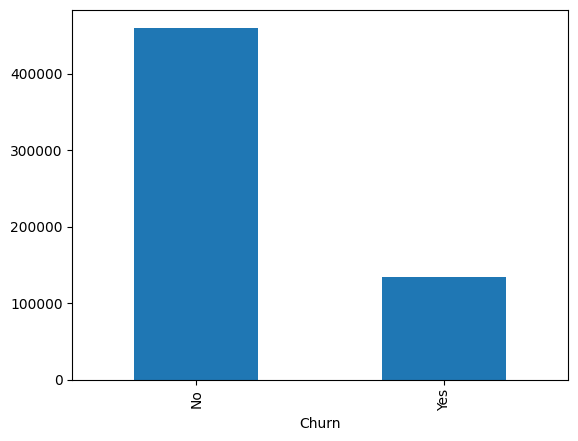

In [8]:
data["Churn"].value_counts().plot(kind='bar')

In [9]:
check = data["Churn"].value_counts()
check["No"] / check["Yes"]

np.float64(3.440347638939746)

From this, we can see that the data is imbalanced, with more customers not churning than those who are. This is something to keep in mind when building our model, as we may need to use techniques to address this imbalance, such as oversampling the minority class or using a different evaluation metric that is more appropriate for imbalanced data.

In [10]:
data['target'] = data['Churn'].map({'No': 0, 'Yes': 1})

## Understanding numeric variables

### One to one relationship

MonthlyCharges       Axes(0.125,0.53;0.227941x0.35)
TotalCharges      Axes(0.398529,0.53;0.227941x0.35)
tenure            Axes(0.672059,0.53;0.227941x0.35)
dtype: object

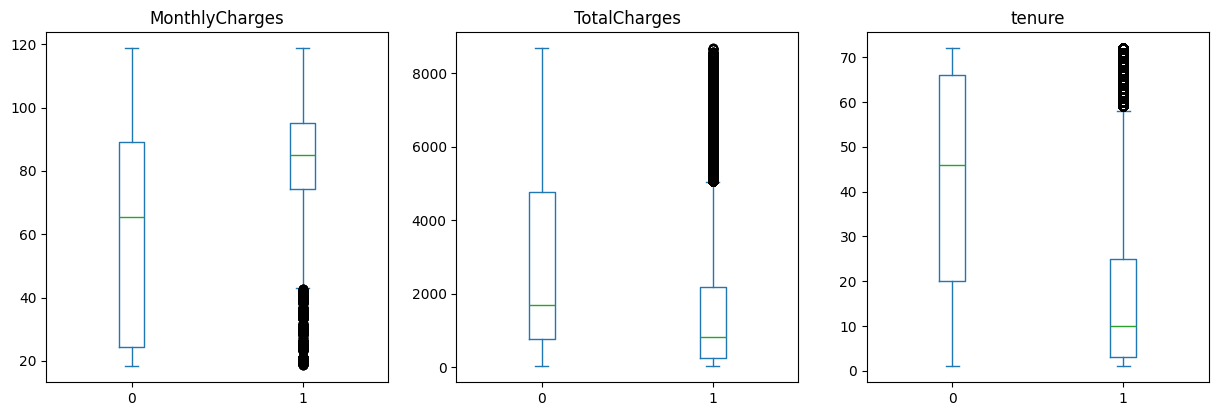

In [11]:
data[numeric_cols + confusion_cols + ['target']].plot(kind='box', subplots=True, layout=(2, 3), figsize=(15, 10), by='target')

We can see that there are many outliers for each of the numeric variables, which is something to keep in mind when building our model. We may need to use techniques to handle these outliers, such as removing them or using a different model that is less sensitive to outliers.

To do Logistic Regression Hypothesis testing, we need to first check whether they are correlated or not. We can do this by looking at the correlation matrix.

In [12]:
data[numeric_cols + confusion_cols + ['target']].corr()

,MonthlyCharges,TotalCharges,tenure,target
MonthlyCharges,1.000000,0.634237,0.124043,0.272997
TotalCharges,0.634237,1.000000,0.769703,-0.218365
tenure,0.124043,0.769703,1.000000,-0.418453
target,0.272997,-0.218365,-0.418453,1.000000


### One to many relationship

We need to check using variance inflation factor (VIF) to check for multicollinearity among the numeric variables. This will help us identify if any of the numeric variables are highly correlated with each other, which can cause issues in our model.

####  What is VIF?

Variance Inflation Factor (VIF) is a measure of how much the variance of a regression coefficient is inflated due to multicollinearity among the independent variables in a regression model. A high VIF indicates that the independent variable is highly correlated with other independent variables, which can lead to unstable estimates of the regression coefficients and make it difficult to interpret the results of the model. Generally, a VIF value greater than 5 or 10 is considered to indicate high multicollinearity, and steps may need to be taken to address this issue, such as removing one of the correlated variables or using regularization techniques.

To understand clearly, what VIF does is the fake regression of one independent variable on all the other independent variables. The R-squared value from this regression is then used to calculate the VIF. A high R-squared value indicates that the independent variable is highly correlated with the other independent variables, which leads to a high VIF.

For example, VIF tries to find the $R^2$ for the regression equation: $TotalCharges = \alpha + \beta_1 \cdot Tenure + \beta_2 \cdot MonthlyCharges + \epsilon$ and then uses the formula $VIF = \frac{1}{1 - R^2}$ to calculate the VIF for TotalCharges. If the VIF is high, it indicates that TotalCharges is highly correlated with Tenure and MonthlyCharges, which can cause issues in our model.

In [13]:
vif_data = pd.DataFrame()
X = sm.add_constant(data[numeric_cols + confusion_cols])
vif_data["feature"] = X.columns
vif_data['vif_score'] = [variance_inflation_factor(X, i) for i in range(X.columns.size)]
vif_data = vif_data.sort_values('vif_score', ascending=False)
vif_data

,feature,vif_score
0,const,18.167195
2,TotalCharges,8.868479
3,tenure,5.383921
1,MonthlyCharges,3.670898


If we remove the variable with the highest VIF, we can then recalculate the VIF for the remaining variables to see if there are any other variables that are still highly correlated with each other. This process can be repeated until we have a set of independent variables that are not highly correlated with each other, which can help improve the stability and interpretability of our model.

In [14]:
vif_data = pd.DataFrame()
X = sm.add_constant(data[["MonthlyCharges", "tenure"]])
vif_data["feature"] = X.columns
vif_data['vif_score'] = [variance_inflation_factor(X, i) for i in range(X.columns.size)]
vif_data = vif_data.sort_values('vif_score', ascending=False)
vif_data

,feature,vif_score
0,const,6.948815
2,tenure,1.015627
1,MonthlyCharges,1.015627


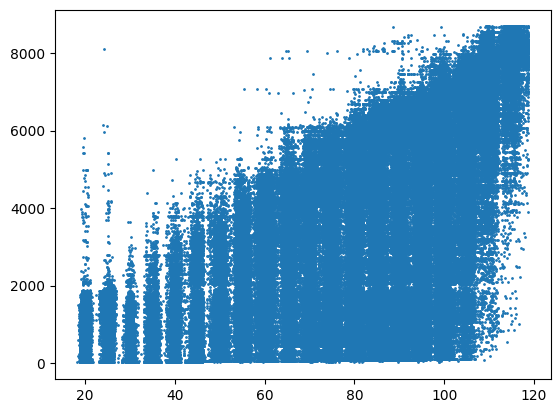

In [15]:
plt.scatter(data['MonthlyCharges'], data['TotalCharges'], s=1)

We can understand that the (`MonthlyCharges`, `TotalCharges`) and (`TotalCharges`, `tenure`) are highly correlated, which makes sense as they are both related to the amount of money a customer is paying. 

We can also see that `tenure` is negatively correlated with `Churn`, which means that customers who have been with the company for a longer period of time are less likely to churn.

We can also plot Logistic Regression Hypothesis Testing to find out that these are very correlated and we can drop one of them to avoid multicollinearity issues in our model.

In [16]:
statsmodels.discrete.discrete_model.Logit(
    data['target'],
    sm.add_constant(data[numeric_cols + confusion_cols])
).fit().summary()

Optimization terminated successfully.
         Current function value: 0.348135
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 target   No. Observations:               594194
Model:                          Logit   Df Residuals:                   594190
Method:                           MLE   Df Model:                            3
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                  0.3474
Time:                        15:15:48   Log-Likelihood:            -2.0686e+05
converged:                       True   LL-Null:                   -3.1696e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.7914      0.018   -153.667      0.000      -2.827      -2.756
MonthlyCharges     0.0485      0.000    198.980      0.000       0.048       0.049
TotalCharges       0.0001   8.46e-06     15.262      0.000       0.000       0.000
tenure            -0.0830      0.001   -103.366      0.000      -0.085      -0.081
==================================================================================
"""

Since `TotalCharges` is highly correlated with both `MonthlyCharges` and `tenure`, we can drop `TotalCharges` from our model to avoid multicollinearity issues. This will help us build a more robust model that is less sensitive to the presence of outliers and multicollinearity.

In [17]:
statsmodels.discrete.discrete_model.Logit(
    data['target'],
    sm.add_constant(data[numeric_cols + confusion_cols].drop('TotalCharges', axis=1))
).fit().summary()

Optimization terminated successfully.
         Current function value: 0.348335
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 target   No. Observations:               594194
Model:                          Logit   Df Residuals:                   594191
Method:                           MLE   Df Model:                            2
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                  0.3470
Time:                        15:15:50   Log-Likelihood:            -2.0698e+05
converged:                       True   LL-Null:                   -3.1696e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.9702      0.014   -209.661      0.000      -2.998      -2.942
MonthlyCharges     0.0507      0.000    255.677      0.000       0.050       0.051
tenure            -0.0713      0.000   -323.213      0.000      -0.072      -0.071
==================================================================================
"""

We can observe that the Psuedo $R^2$ value is 0.3470, which indicates that the model is able to reduce the negative likelihood by 34.70% compared to a null model that only includes the intercept. This suggests that the independent variables in the model are able to explain a significant portion of the variance in the dependent variable (Churn), and that the model is a good fit for the data. However, it is important to note that Psuedo $R^2$ values can be difficult to interpret and should be used in conjunction with other metrics, such as AIC or BIC, to evaluate the performance of the model.

### Now, what is Psuedo $R^2$?

$$Psuedo-R^2 = 1 - \frac{\ln(L_M)}{\ln(L_0)}$$

Where:
- $L_M$ is the likelihood of the fitted model
- $L_0$ is the likelihood of the null model (intercept-only model)

In [18]:
lr_numerical = LogisticRegression()
X = data[numeric_cols + confusion_cols].drop('TotalCharges', axis=1)
y = data['target']
lr_numerical.fit(X, y)
lr_numerical_predictions = lr_numerical.predict_proba(X)[:, 1]
roc_auc_score(y, lr_numerical_predictions)

0.8808067770030472

## Understanding categorical columns

In [19]:
data[categorical_cols + confusion_cols]

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,tenure
0,Male,0,Yes,Yes,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,29
1,Male,0,Yes,Yes,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),58
2,Male,0,Yes,No,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,58
3,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,1
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),57
594190,Female,0,No,No,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),72
594191,Female,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),72
594192,Female,0,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,32


In [32]:
tenure_cat = OneHotEncoder(drop='first', sparse_output=False)
tenure_cat_data = tenure_cat.fit_transform(data[confusion_cols])
tenure_cat_df = pd.DataFrame(tenure_cat_data, columns=tenure_cat.get_feature_names_out(confusion_cols))
tenure_cat_df = pd.concat([tenure_cat_df, data["target"]], axis=1)
tenure_cat_df.head()

,tenure_2,tenure_3,tenure_4,tenure_5,tenure_6,tenure_7,tenure_8,tenure_9,tenure_10,tenure_11,...,tenure_64,tenure_65,tenure_66,tenure_67,tenure_68,tenure_69,tenure_70,tenure_71,tenure_72,target
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


<Axes: >

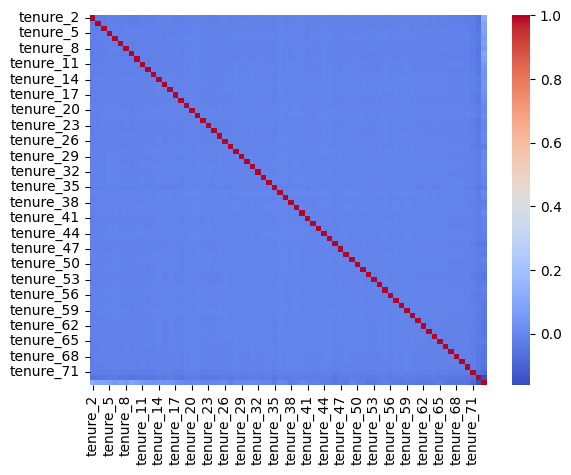

In [36]:
sns.heatmap(tenure_cat_df.corr(), cmap='coolwarm')

In [27]:
cat_ohc = OneHotEncoder(drop='first', sparse_output=False)
cat_ohc_data = cat_ohc.fit_transform(data[categorical_cols])
cat_ohc_df = pd.DataFrame(cat_ohc_data, columns=cat_ohc.get_feature_names_out(categorical_cols))
cat_ohc_df.head()

,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


<Axes: >

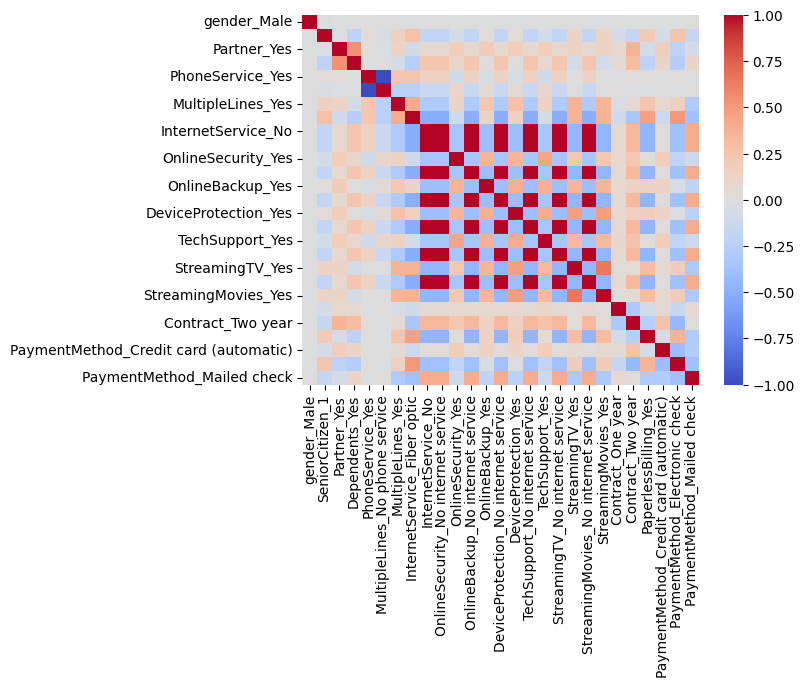

In [34]:
sns.heatmap(cat_ohc_df.corr(), fmt=".2f", cmap='coolwarm')

There seems to be relation between various categorical columns and the target variable, which is something to keep in mind when building our model. We may need to use techniques to handle these categorical variables, such as one-hot encoding or using a different model that can handle categorical variables directly.

In [35]:
vif_data = pd.DataFrame()
X = sm.add_constant(cat_ohc_df)
vif_data["feature"] = X.columns
vif_data['vif_score'] = [variance_inflation_factor(X, i) for i in range(X.columns.size)]
vif_data = vif_data.sort_values('vif_score', ascending=False)
vif_data

c:\MY FILES\Peeyush-Personal\Coding\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,feature,vif_score
6,MultipleLines_No phone service,4.503600e+15
18,StreamingTV_No internet service,2.954982e+10
10,OnlineSecurity_No internet service,1.363554e+10
9,InternetService_No,1.363554e+10
12,OnlineBackup_No internet service,2.789316e+09
14,DeviceProtection_No internet service,2.240757e+09
16,TechSupport_No internet service,1.146858e+09
5,PhoneService_Yes,1.109374e+09
20,StreamingMovies_No internet service,6.265045e+08
23,Contract_Two year,2.745541e+00
